In [78]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

# data loading and initial assessment

In [2]:
df = pd.read_csv("student-mat.csv",sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info(memory_usage = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
school        395 non-null object
sex           395 non-null object
age           395 non-null int64
address       395 non-null object
famsize       395 non-null object
Pstatus       395 non-null object
Medu          395 non-null int64
Fedu          395 non-null int64
Mjob          395 non-null object
Fjob          395 non-null object
reason        395 non-null object
guardian      395 non-null object
traveltime    395 non-null int64
studytime     395 non-null int64
failures      395 non-null int64
schoolsup     395 non-null object
famsup        395 non-null object
paid          395 non-null object
activities    395 non-null object
nursery       395 non-null object
higher        395 non-null object
internet      395 non-null object
romantic      395 non-null object
famrel        395 non-null int64
freetime      395 non-null int64
goout         395 non-null int64
Dalc          395 no

In [4]:
col = df.columns
col

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [5]:
df.shape

(395, 33)

# data cleaning

In [6]:
df.isnull().sum().head()

school     0
sex        0
age        0
address    0
famsize    0
dtype: int64

In [7]:
df.nunique().head()

school     2
sex        2
age        8
address    2
famsize    2
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
num = df._get_numeric_data()
cat = df.drop(columns = num.columns)
num.describe(include='all')

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [10]:
cat.describe(include='all')

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263


# exploratory data analysis

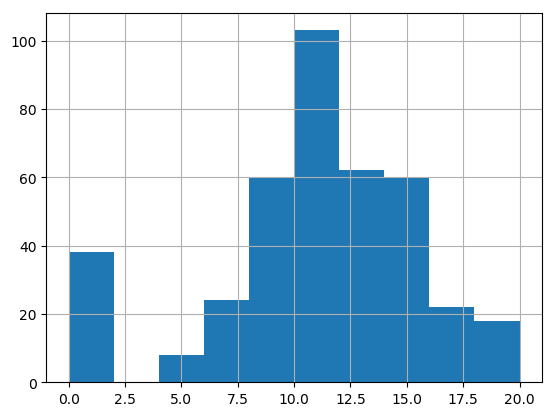

In [11]:
num['G3'].hist()

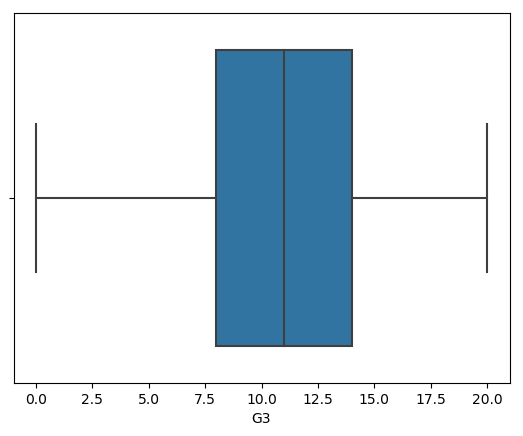

In [12]:
sns.boxplot(x=num['G3'])

In [13]:
num['G3'].skew()

-0.7326723530443433

In [18]:
num.corr()['G3'].sort_values()

failures     -0.360415
age          -0.161579
goout        -0.132791
traveltime   -0.117142
health       -0.061335
Dalc         -0.054660
Walc         -0.051939
freetime      0.011307
absences      0.034247
famrel        0.051363
studytime     0.097820
Fedu          0.152457
Medu          0.217147
G1            0.801468
G2            0.904868
G3            1.000000
Name: G3, dtype: float64

# feature engineering

In [39]:
clean_data = pd.concat([num,cat],axis=1)
clean_data.shape

(395, 33)

In [41]:
clean_data = pd.get_dummies(clean_data,columns=cat.columns,drop_first=True)
clean_data.shape

(395, 42)

In [49]:
clean_data.dtypes

age                  int64
Medu                 int64
Fedu                 int64
traveltime           int64
studytime            int64
failures             int64
famrel               int64
freetime             int64
goout                int64
Dalc                 int64
Walc                 int64
health               int64
absences             int64
G1                   int64
G2                   int64
G3                   int64
school_MS            uint8
sex_M                uint8
address_U            uint8
famsize_LE3          uint8
Pstatus_T            uint8
Mjob_health          uint8
Mjob_other           uint8
Mjob_services        uint8
Mjob_teacher         uint8
Fjob_health          uint8
Fjob_other           uint8
Fjob_services        uint8
Fjob_teacher         uint8
reason_home          uint8
reason_other         uint8
reason_reputation    uint8
guardian_mother      uint8
guardian_other       uint8
schoolsup_yes        uint8
famsup_yes           uint8
paid_yes             uint8
a

In [56]:
cat_cols = cat.columns
result = {}
for col in cat_cols:
    groups = [group['G3'].values for name,group in df.groupby(col)]
    if len(groups) > 1:
        stat, p = f_oneway(*groups)
        result[col] = p
        
anova_results = pd.DataFrame.from_dict(result,orient="index",columns=['p_value'])
anova_results.sort_values(by="p_value")

,p_value
higher,0.000267
Mjob,0.005195
romantic,0.009713
address,0.035633
sex,0.039865
paid,0.042765
internet,0.050480
schoolsup,0.100385
reason,0.102337
famsize,0.106205


In [59]:
x = clean_data.drop(columns=['G3'])
y = clean_data['G3']

In [62]:
x.shape

(395, 41)

# preprocessing

In [71]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(316, 41)
(79, 41)
(316,)
(79,)


In [72]:
scaler = StandardScaler()
x_ttr = scaler.fit_transform(x_train)
x_ttt = scaler.transform(x_test)

# model train

In [75]:
model = LinearRegression()
model.fit(x_ttr,y_train)
y_ptt = model.predict(x_ttt)
y_ptr = model.predict(x_ttr)





# model evaluation

In [81]:
mse_tr = mean_squared_error(y_train,y_ptr)
mse_tt = mean_squared_error(y_test,y_ptt)
r2_tr = r2_score(y_train,y_ptr)
r2_tt = r2_score(y_test,y_ptt)
print("train mse:",mse_tr)
print("test mse:",mse_tt)
print("train r2:",r2_tr)
print("test r2:",r2_tt)

train mse: 2.9523973027685764
test mse: 5.163182800481563
train r2: 0.8506277907406686
test r2: 0.798381820891697
